## 1. What this notebook computes

The Lovelock tensors of chapter 11 are long sums of products of the curvature of the
author's metric. Every term of these sums carries a weight that is the value of the
**generalized Kronecker delta**, a number $+1$, $-1$ or $0$ that depends on two lists
of coordinate labels. The author defined it, in his Mathematica notebook, as the
determinant of a matrix of zeros and ones. The Revision Rust program `lovelock_gkd`
computes it with a faster rule, the function **GKD**. This notebook

- writes the author's definition literally in Python (a determinant computed exactly
  by sympy) and evaluates it on examples;
- proves that the determinant is always the sign of a permutation or zero, writes
  this rule (GKD) in Python, and checks that the two agree on all 266,304 pairs of
  index lists of length 1, 2 and 3 over the eight labels $x_1, \dots, x_8$, and on
  12,000 pseudo-random pairs of length 4 to 9;
- counts how often the values $+1$, $-1$ and $0$ occur, derives the counts with a
  formula, and reproduces the counts recorded by the Revision's Wolfram check;
- shows that a delta with nine or more indices is always zero in eight dimensions
  (the pigeonhole principle), which is why the Lovelock sum stops at order 3;
- measures that the rule is much faster than the determinant and draws the cost of
  both;
- builds the Revision Rust program `lovelock_gkd` with cargo and runs its GKD
  self-test, which compares GKD with the literal determinant on 16,777,216 pairs of
  length 4 and on 200,000 random pairs of each length 5 to 9, and checks that the
  program writes exactly the committed Revision record
  `Revision/gkd_lovelock/results/gkd-selftest.json`, byte for byte;
- reads the Revision records once more and checks that every check and number it
  quotes from them is there, every quoted check with the verdict PASS.

It draws six figures. The Rust self-test takes 7 to 13 minutes; everything else
takes about a minute.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 11a (The generalized Kronecker delta GKD in Python and in Rust) is the file
`Revision/textbook/notebooks/11a_kronecker_delta_gkd.ipynb` of the repository
Dirac_claude. It writes the author's generalized Kronecker delta literally as the
determinant of a matrix of zeros and ones, proves and checks that it equals the sign of a
permutation or zero (the rule of the Rust function GKD), compares the two for all 266,304
pairs of index lists of length 1, 2 and 3 over the eight coordinate labels and for 12,000
random pairs of length 4 to 9, counts how often the values +1, -1 and 0 occur and derives
these counts by a formula, shows why the delta of nine indices in eight dimensions is
always zero, and builds the Revision Rust program lovelock_gkd with cargo inside the
notebook when the program file is missing (a few seconds, up to a minute on a slow
computer; about a second when it is up to date), runs its GKD self-test (16,777,216 pairs
of length 4 compared exhaustively; this cell alone takes 7 to 13 minutes) and checks that
it reproduces the committed Revision record byte for byte; it checks again that every
check and number it quotes from the Revision records is there, with the verdict PASS; it
draws six teaching figures. The Rust program writes its result file gkd-selftest.json
into the folder `Revision/gkd_lovelock/code/target/textbook_11a`, inside the Rust build
folder, which git ignores. It needs a computer with Windows 11, macOS or Linux, an
internet connection for the installation, the program Git, and Python 3.12 or newer (the
notebooks were built with Python 3.14.5) with these packages at exactly these versions:
numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat
5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself
imports numpy, sympy and matplotlib; the other packages run Jupyter, the program that
shows and runs notebooks. It also needs Rust (the program cargo, version 1.91.1 or
newer), because it runs the Rust program lovelock_gkd, which is part of the repository
and is built on your computer.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Install Rust and build the Rust program (Rust once per computer, the build once
per program).**

Windows: download `rustup-init.exe` from https://rustup.rs, run it and accept the default
choices; if it reports that the Visual Studio C++ Build Tools are missing, let it install
them (or install the workload "Desktop development with C++" from
https://visualstudio.microsoft.com/visual-cpp-build-tools/ and run `rustup-init.exe`
again). macOS and Linux: run the command below and accept the default choice (on Linux
first run `sudo apt install build-essential`, which provides the linker that Rust needs).

macOS (zsh) and Linux (bash):

    curl --proto "=https" --tlsv1.2 -sSf https://sh.rustup.rs | sh

Then close the terminal, open a new one, do Step 4 again, and check the version of cargo;
it must print 1.91.1 or a newer version:

Windows, macOS and Linux:

    cargo --version

Build the program with the following command, in the repository folder (the same command
on all three systems):

Windows, macOS and Linux:

    cargo build --release --manifest-path Revision/gkd_lovelock/code/Cargo.toml

The first build takes about 1 minute; later builds reuse the result and take a few
seconds. The program is then the file
`Revision/gkd_lovelock/code/target/release/lovelock_gkd` (on Windows with the ending
`.exe`). The notebook runs the same build command itself before it uses the program (it
takes a second when the program is up to date), so the notebook also works if you skip
this build; building here first shows any problem with Rust before the notebook starts.

**Step 6. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 11a_kronecker_delta_gkd.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 13 minutes on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 7. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 11a_kronecker_delta_gkd.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
11a_kronecker_delta_gkd.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 8. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/11a.captions.json`
- `Revision/textbook/figures/11a_1_outer_delta_matrices.png`
- `Revision/textbook/figures/11a_2_six_permutations.png`
- `Revision/textbook/figures/11a_3_gkd_map_length_two.png`
- `Revision/textbook/figures/11a_4_value_counts.png`
- `Revision/textbook/figures/11a_5_cost_of_the_determinant.png`
- `Revision/textbook/figures/11a_6_all_labels_different.png`

It changes no other file of the repository except the Rust build folder `target` next to
each `Cargo.toml` it builds (inside it the notebook keeps the raw output of its program
runs in `Revision/gkd_lovelock/code/target/textbook_11a`, which git ignores); running it
headless or saving it in JupyterLab also rewrites the notebook file itself. It does not
use the internet while it runs. The files it writes are the same files that are stored in
the repository (on another computer a figure may differ in a few bytes, which is
harmless). To get the stored versions back, run this command in the repository folder (it
also undoes every change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all six figure files of the notebook exist
    ALL 24 CHECKS PASSED (notebook 11a)

and the notebook must show 6 figures below the cells that draw them.

**Step 9. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/11a_kronecker_delta_gkd.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4. If the environment is active and the message stays, the programs
  jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
  programs (`python -m jupyter` does not help then: it has to find the same programs).
  Start them through Python itself, in the folder of the notebook: the first command
  below does what `jupyter lab` does, the second what the headless command does:

      python -m jupyterlab 11a_kronecker_delta_gkd.ipynb
      python -m nbconvert --execute --inplace 11a_kronecker_delta_gkd.ipynb

- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "cargo is not recognized" or "command not found: cargo" or "cargo was not found": open
  a new terminal after installing Rust, do Step 4 again, and start JupyterLab from this
  terminal.
- "linker link.exe not found" (Windows) or "linker cc not found" (Linux): install the C++
  Build Tools (Windows) or build-essential (Linux) as described in Step 5 and build
  again.
- The notebook seems to hang at the cell that runs the Rust self-test: It does not hang.
  The self-test compares 16,777,216 pairs of index lists of length 4 and then 200,000
  random pairs of each length 5 to 9 with the literal determinant, and the 200,000
  determinants of nine by nine matrices alone take several minutes, because each one is a
  sum of 362,880 products. Wait until the label to the left of the cell shows a number;
  the whole notebook takes 8 to 15 minutes, longer when the computer is busy with other
  work.
- AssertionError: check failed: the program wrote gkd-selftest.json equal to the Revision
  record byte for byte: The file that the program wrote differs from the committed
  record. Run git status in the repository folder to see whether the record or the Rust
  source was changed, and restore both with the command below.

      git checkout -- Revision/gkd_lovelock

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 11a (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 11a (The generalized Kronecker delta GKD in Python and in Rust) is the file
# Revision/textbook/notebooks/11a_kronecker_delta_gkd.ipynb of the repository
# Dirac_claude. It writes the author's generalized Kronecker delta literally as the
# determinant of a matrix of zeros and ones, proves and checks that it equals the sign of
# a permutation or zero (the rule of the Rust function GKD), compares the two for all
# 266,304 pairs of index lists of length 1, 2 and 3 over the eight coordinate labels and
# for 12,000 random pairs of length 4 to 9, counts how often the values +1, -1 and 0
# occur and derives these counts by a formula, shows why the delta of nine indices in
# eight dimensions is always zero, and builds the Revision Rust program lovelock_gkd with
# cargo inside the notebook when the program file is missing (a few seconds, up to a
# minute on a slow computer; about a second when it is up to date), runs its GKD
# self-test (16,777,216 pairs of length 4 compared exhaustively; this cell alone takes 7
# to 13 minutes) and checks that it reproduces the committed Revision record byte for
# byte; it checks again that every check and number it quotes from the Revision records
# is there, with the verdict PASS; it draws six teaching figures. The Rust program writes
# its result file gkd-selftest.json into the folder
# Revision/gkd_lovelock/code/target/textbook_11a, inside the Rust build folder, which git
# ignores. It needs a computer with Windows 11, macOS or Linux, an internet connection
# for the installation, the program Git, and Python 3.12 or newer (the notebooks were
# built with Python 3.14.5) with these packages at exactly these versions: numpy 2.4.6,
# sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4,
# nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports
# numpy, sympy and matplotlib; the other packages run Jupyter, the program that shows and
# runs notebooks. It also needs Rust (the program cargo, version 1.91.1 or newer),
# because it runs the Rust program lovelock_gkd, which is part of the repository and is
# built on your computer.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. INSTALL RUST AND BUILD THE RUST PROGRAM (RUST ONCE PER COMPUTER, THE BUILD ONCE
# PER PROGRAM).
#
# Windows: download rustup-init.exe from https://rustup.rs, run it and accept the default
# choices; if it reports that the Visual Studio C++ Build Tools are missing, let it
# install them (or install the workload "Desktop development with C++" from
# https://visualstudio.microsoft.com/visual-cpp-build-tools/ and run rustup-init.exe
# again). macOS and Linux: run the command below and accept the default choice (on Linux
# first run sudo apt install build-essential, which provides the linker that Rust needs).
#
# macOS (zsh) and Linux (bash):
#     curl --proto "=https" --tlsv1.2 -sSf https://sh.rustup.rs | sh
#
# Then close the terminal, open a new one, do Step 4 again, and check the version of
# cargo; it must print 1.91.1 or a newer version:
#
# Windows, macOS and Linux:
#     cargo --version
#
# Build the program with the following command, in the repository folder (the same
# command on all three systems):
#
# Windows, macOS and Linux:
#     cargo build --release --manifest-path Revision/gkd_lovelock/code/Cargo.toml
#
# The first build takes about 1 minute; later builds reuse the result and take a few
# seconds. The program is then the file
# Revision/gkd_lovelock/code/target/release/lovelock_gkd (on Windows with the ending
# .exe). The notebook runs the same build command itself before it uses the program (it
# takes a second when the program is up to date), so the notebook also works if you skip
# this build; building here first shows any problem with Rust before the notebook starts.
#
# STEP 6. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 11a_kronecker_delta_gkd.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 13
# minutes on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 7. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 11a_kronecker_delta_gkd.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 11a_kronecker_delta_gkd.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 8. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/11a.captions.json
# - Revision/textbook/figures/11a_1_outer_delta_matrices.png
# - Revision/textbook/figures/11a_2_six_permutations.png
# - Revision/textbook/figures/11a_3_gkd_map_length_two.png
# - Revision/textbook/figures/11a_4_value_counts.png
# - Revision/textbook/figures/11a_5_cost_of_the_determinant.png
# - Revision/textbook/figures/11a_6_all_labels_different.png
#
# It changes no other file of the repository except the Rust build folder target next to
# each Cargo.toml it builds (inside it the notebook keeps the raw output of its program
# runs in Revision/gkd_lovelock/code/target/textbook_11a, which git ignores); running it
# headless or saving it in JupyterLab also rewrites the notebook file itself. It does not
# use the internet while it runs. The files it writes are the same files that are stored
# in the repository (on another computer a figure may differ in a few bytes, which is
# harmless). To get the stored versions back, run this command in the repository folder
# (it also undoes every change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all six figure files of the notebook exist
#     ALL 24 CHECKS PASSED (notebook 11a)
#
# and the notebook must show 6 figures below the cells that draw them.
#
# STEP 9. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/11a_kronecker_delta_gkd.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4. If the environment is active and the message stays, the programs
#   jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
#   programs (python -m jupyter does not help then: it has to find the same programs).
#   Start them through Python itself, in the folder of the notebook: the first command
#   below does what jupyter lab does, the second what the headless command does:
#     python -m jupyterlab 11a_kronecker_delta_gkd.ipynb
#     python -m nbconvert --execute --inplace 11a_kronecker_delta_gkd.ipynb
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "cargo is not recognized" or "command not found: cargo" or "cargo was not found":
#   open a new terminal after installing Rust, do Step 4 again, and start JupyterLab from
#   this terminal.
# - "linker link.exe not found" (Windows) or "linker cc not found" (Linux): install the
#   C++ Build Tools (Windows) or build-essential (Linux) as described in Step 5 and build
#   again.
# - The notebook seems to hang at the cell that runs the Rust self-test: It does not
#   hang. The self-test compares 16,777,216 pairs of index lists of length 4 and then
#   200,000 random pairs of each length 5 to 9 with the literal determinant, and the
#   200,000 determinants of nine by nine matrices alone take several minutes, because
#   each one is a sum of 362,880 products. Wait until the label to the left of the cell
#   shows a number; the whole notebook takes 8 to 15 minutes, longer when the computer is
#   busy with other work.
# - AssertionError: check failed: the program wrote gkd-selftest.json equal to the
#   Revision record byte for byte: The file that the program wrote differs from the
#   committed record. Run git status in the repository folder to see whether the record
#   or the Rust source was changed, and restore both with the command below.
#     git checkout -- Revision/gkd_lovelock
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell
import shutil  # finds the program cargo
import subprocess  # runs cargo and the Rust programs

NOTEBOOK_ID = "11a"  # this notebook: chapter 11, example a


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


def rust_program(manifest, binary):
    """Build the Rust program binary of the crate whose Cargo.toml is manifest (a
    repository path) with "cargo build --release" (about a second when it is up to date;
    minutes the first time) and return the path of the program."""
    if shutil.which("cargo") is None:
        raise FileNotFoundError(
            "cargo was not found: install Rust from https://rustup.rs, open a new "
            "terminal, activate the environment and start JupyterLab again")
    crate = (REPO / manifest).parent  # the folder that holds Cargo.toml
    completed = subprocess.run(
        ["cargo", "build", "--release", "--manifest-path", str(REPO / manifest),
         "--target-dir", str(crate / "target")],
        capture_output=True, text=True, encoding="utf-8", errors="replace")
    if completed.returncode != 0:  # show the end of cargo's error message
        print(completed.stderr[-3000:])
        raise RuntimeError(f"cargo build failed for {manifest}")
    for file_name in (binary, binary + ".exe"):  # Linux and macOS; Windows
        path = crate / "target" / "release" / file_name
        if path.is_file():
            say(f"Rust program {binary} is built and ready.")
            return path
    raise FileNotFoundError(f"cargo built {manifest} but {binary} is missing")

say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 11a complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Coordinate label**: the name of one of the eight coordinates $x_1, \dots, x_8$ of
  the author's metric ($x_1, x_2, x_3$ ordinary space, $x_4$ the time, $x_5, x_6,
  x_7$ the three extra times, which deflate exponentially, $x_8$ the hidden
  direction). Programs number them
  $0, 1, \dots, 7$: the number 0 stands for $x_1$, the number 7 for $x_8$.
- **Index list**: a list of labels such as $(x_2, x_1, x_4)$; its **length** $p$ is
  the number of entries. Two lists of the same length are a **pair**: the
  **lower** list $(l_1, \dots, l_p)$ and the **upper** list $(u_1, \dots, u_p)$.
- **Kronecker delta** $\delta(a, b)$: the number 1 if the labels $a$ and $b$ are
  equal and 0 if they are different.
- **Matrix, entry, row, column**: a matrix is a rectangle of numbers; the number in
  row $i$ and column $j$ is the entry $M_{ij}$. A **0/1 matrix** has only the
  entries 0 and 1.
- **Outer[delta, lower, upper]**: the author's Mathematica name for the $p \times p$
  matrix with the entries $M_{ij} = \delta(l_i, u_j)$: row $i$ belongs to the lower
  label $l_i$, column $j$ to the upper label $u_j$.
- **Permutation**: a rearrangement of $p$ objects; we describe it by the list
  $(\sigma(1), \dots, \sigma(p))$ that says where object $i$ goes. There are
  $p! = 1 \cdot 2 \cdots p$ permutations of $p$ objects ($p!$ is read
  "$p$ factorial").
- **Inversion**: a pair of places $i < j$ with $\sigma(i) > \sigma(j)$, that is, two
  objects that the permutation puts in the opposite order.
- **Sign of a permutation**: $\mathrm{sign}(\sigma) = (-1)^{N}$, where $N$ is the
  number of inversions: $+1$ for an **even** permutation (even $N$), $-1$ for an
  **odd** one. A **transposition** exchanges two objects.
- **Determinant** (Leibniz formula): for a $p \times p$ matrix $M$,
  $\det M = \sum_{\pi} \mathrm{sign}(\pi)\, M_{1\pi(1)} M_{2\pi(2)} \cdots
  M_{p\pi(p)}$, a sum of $p!$ products, one for every permutation $\pi$.
- **Generalized Kronecker delta**: the number
  $\delta^{u_1 \dots u_p}_{l_1 \dots l_p} = \det[\delta(l_i, u_j)]$; the author
  writes it k$\delta$[lower, upper].
- **GKD**: the name of the Rust function of the Revision program that computes the
  generalized Kronecker delta by the permutation rule proved in this notebook.
- **Exhaustive test**: a test of every possible case. **Pseudo-random numbers**:
  numbers made by a fixed recipe that look random; the recipe starts from a number
  called the **seed**, and the same seed gives the same numbers on every computer.
- **Pigeonhole principle**: if more than $n$ objects are put into $n$ boxes, some
  box holds two objects.
- **Rust, cargo, program**: Rust is a programming language; cargo builds a Rust
  **crate** (a folder with a file `Cargo.toml` and source files) into a program file
  that the computer runs.
- **Revision record**: a file committed under `Revision/` that holds a result of the
  Revision computations. **Byte for byte**: two files are equal in every byte, so
  they are the same file.

## 4. The physical and mathematical situation

**Why the delta is needed.** In eight dimensions Lovelock's equation (4.38), which
the author's notebook quotes, adds to Einstein's tensor two more tensors built from
products of two and of three curvature tensors. Written out, the tensor of order $k$
is a sum over $2k$ upper and $2k$ lower coordinate labels plus one free pair, and
every term is weighted by a generalized Kronecker delta with $p = 2k + 1$ upper and
$2k + 1$ lower labels. For the 64 components of the tensor of order $k = 3$ the
program `lovelock_gkd` evaluates the delta 495,360 times (record
`Revision/gkd_lovelock/results/lovelock-report.json`, counter `gkdCalls`). So the
delta must be right and fast.

**The author's definition.** The Revision record
`Revision/gkd_lovelock/results/PROVENANCE_OF_THE_COMPUTATION.md` quotes it from the
input cell In[54] of the author's notebook (with $\delta$ written as delta here):

    kdelta[lower_, upper_] /; Length[lower] == Length[upper] :=
        Det[Outer[delta, lower, upper]]

In words: for two lists of the same length $p$, build the $p \times p$ matrix
$M_{ij} = \delta(l_i, u_j)$ and take its determinant. For lists of different
lengths the definition gives nothing (Mathematica leaves the expression
unevaluated). For $p = 1$ the matrix is the single number $\delta(l_1, u_1)$, so the
generalized delta is the ordinary Kronecker delta. For $p = 2$,

$$\delta^{u_1 u_2}_{l_1 l_2} = \delta(l_1, u_1)\,\delta(l_2, u_2)
  - \delta(l_1, u_2)\,\delta(l_2, u_1),$$

by the formula $\det = M_{11} M_{22} - M_{12} M_{21}$ of a $2 \times 2$
determinant.

**Theorem (the rule GKD).** Let $M_{ij} = \delta(l_i, u_j)$. Then $\det M = 0$ when
a label appears twice in the lower list, or twice in the upper list, or when some
lower label is missing from the upper list; otherwise $\det M =
\mathrm{sign}(\sigma)$, where $\sigma(i)$ is the place of $l_i$ in the upper list.

*Proof, case by case.*

(a) Two equal lower labels, $l_i = l_k$ with $i \ne k$. Then row $i$ and row $k$ of
$M$ are equal, because $M_{ij} = \delta(l_i, u_j) = \delta(l_k, u_j) = M_{kj}$ for
every column $j$. Exchanging two rows of a matrix changes the sign of its
determinant; exchanging two EQUAL rows does not change the matrix. So
$\det M = -\det M$, which gives $2 \det M = 0$ and $\det M = 0$.

(b) Two equal upper labels, $u_j = u_k$. Then columns $j$ and $k$ are equal, and the
same argument for columns (a matrix and its transpose have the same determinant)
gives $\det M = 0$.

(c) Some lower label $l_i$ equals no upper label. Then row $i$ is all zeros. Every
product in the Leibniz formula contains exactly one entry of row $i$, so every
product is zero, and $\det M = 0$.

(d) Otherwise the $p$ lower labels are different, the $p$ upper labels are
different, and every lower label appears in the upper list. Then $l_i$ equals
exactly one upper label, $u_{\sigma(i)}$. Different lower labels sit at different
places, so $\sigma$ sends the places $1, \dots, p$ to the places $1, \dots, p$
without repetition: $\sigma$ is a permutation. Row $i$ of $M$ has a single 1, in
column $\sigma(i)$. In the Leibniz formula the product for a permutation $\pi$ is
$M_{1\pi(1)} \cdots M_{p\pi(p)}$; it is 1 if $\pi(i) = \sigma(i)$ for every $i$ and
0 otherwise. So only the term $\pi = \sigma$ survives, and
$\det M = \mathrm{sign}(\sigma) \cdot 1 = \mathrm{sign}(\sigma)$. End of proof.

The rule needs only about $p^2/2$ comparisons of two numbers, while the Leibniz
formula adds $p!$ products. For $p = 7$ that is 21 comparisons against 5,040
products.

**How many pairs give $+1$, $-1$ and $0$.** A lower list of $p$ DIFFERENT labels out
of 8 can be chosen in $8 \cdot 7 \cdots (8 - p + 1) = 8!/(8 - p)!$ ways (8 choices
for the first label, 7 for the second, and so on). The delta is nonzero exactly
when the upper list holds the same $p$ labels in some order: $p!$ orders. Hence the
number of pairs with a nonzero delta is

$$N_{\ne 0}(p) = \frac{8!}{(8 - p)!}\, p!,$$

out of $8^p \cdot 8^p = 8^{2p}$ pairs. For $p \ge 2$ exactly half of the $p!$ orders
are even. To see this, exchange the first two labels of the upper list. In the list
$\sigma$ this exchanges the values 1 and 2 (the places of these two labels). The two
entries of $\sigma$ that hold the values 1 and 2 change their relative order, so the
pair they form becomes an inversion if it was none, and stops being one if it was
one. Every other pair of entries is compared as before: a pair that contains
neither of the two entries is unchanged, and an entry with a value of 3 or more is
larger than both 1 and 2, so its comparison with either of them gives the same
answer. Hence the number of inversions changes by exactly one: the exchange turns
every even order into an odd one and back, and so pairs the even orders one to one
with the odd orders. For $p = 1$ the only order is the identity, which is even. So
$p = 1$ gives 8 values $+1$; $p = 2$ gives $56 \cdot 2 = 112$ nonzero values, 56 of
each sign; $p = 3$ gives $336 \cdot 6 = 2016$, 1008 of each sign.

**Nine labels in eight dimensions.** A list of 9 labels taken from 8 must repeat a
label (pigeonhole principle), so by case (a) every delta with $p \ge 9$ is zero. The
Lovelock tensor of order $k$ needs $p = 2k + 1$: $p = 3, 5, 7$ for $k = 1, 2, 3$ and
$p = 9$ for $k = 4$. That is why the Lovelock sum in eight dimensions stops at
$k = 3$.

**Status.** The theorem is PROVED above (exact). The comparisons below are
COMPUTED checks of the proof and of the two programs.

## 5. The literal definition: a determinant of zeros and ones

The next cell imports the packages and defines two functions. `outer_delta(lower,
upper)` builds the matrix Outer[delta, lower, upper] as a list of rows.
`kdelta(lower, upper)` is the author's definition: it refuses two lists of different
lengths and returns the determinant of that matrix, computed EXACTLY by sympy
(`sp.Matrix(...).det()` gives a whole number, not a decimal approximation). Because
many different pairs of lists give the same 0/1 matrix, `kdelta` remembers every
determinant it has computed in the dictionary `DETERMINANTS` and computes each
matrix only once.

Then it evaluates the five examples of the Revision record
`python-lovelock-report.json` (check `gkd_examples`), whose lists use the labels
1, 2, 3, 4 (any whole numbers can serve as labels: only equality of two labels
matters).

In [2]:
import itertools  # loops over all lists of labels, and over all permutations
import math  # factorials n! and the numbers n!/(n-p)!
import re  # regular expressions: reads numbers out of a program's printed text
import time  # a stopwatch (used inside one check; no time is ever printed)

import numpy as np  # arrays of numbers and pseudo-random numbers
import sympy as sp  # exact algebra: sympy computes determinants exactly

NAMES = ["x1", "x2", "x3", "x4", "x5", "x6", "x7", "x8"]  # the labels 0..7 by name


def outer_delta(lower, upper):
    """The matrix Outer[delta, lower, upper] as a list of rows: the entry in row i
    and column j is 1 if lower[i] equals upper[j], else 0."""
    return [[1 if a == b else 0 for b in upper] for a in lower]


DETERMINANTS = {}  # memory: a matrix (a tuple of rows) -> its determinant


def kdelta(lower, upper):
    """The author's generalized Kronecker delta, literally: the exact determinant
    of Outer[delta, lower, upper].  Two lists of different lengths are refused."""
    if len(lower) != len(upper):
        raise ValueError("kdelta needs two index lists of the same length")
    matrix = tuple(tuple(row) for row in outer_delta(lower, upper))
    if matrix not in DETERMINANTS:  # each different matrix is computed only once
        DETERMINANTS[matrix] = int(sp.Matrix(matrix).det())
    return DETERMINANTS[matrix]


EXAMPLES = [  # (lower list, upper list, value stated in the Revision record)
    ((1, 2), (1, 2), 1),
    ((1, 2), (2, 1), -1),
    ((1, 1), (1, 1), 0),
    ((1, 2, 3), (2, 3, 1), 1),
    ((1, 2, 3), (1, 2, 4), 0),
]
for lower, upper, stated in EXAMPLES:
    say(f"kdelta[{list(lower)}, {list(upper)}] = {kdelta(lower, upper)}   "
        f"(the record states {stated})")
check(all(kdelta(lower, upper) == stated for lower, upper, stated in EXAMPLES),
      "the five examples give 1, -1, 0, 1, 0",
      record="Revision/gkd_lovelock/results/python-lovelock-report.json, "
             "check gkd_examples")
try:  # lists of different lengths must be refused, as in the author's definition
    kdelta((1,), (1, 2))
    refused = False
except ValueError:
    refused = True
check(refused, "kdelta refuses two lists of different lengths")

kdelta[[1, 2], [1, 2]] = 1   (the record states 1)
kdelta[[1, 2], [2, 1]] = -1   (the record states -1)
kdelta[[1, 1], [1, 1]] = 0   (the record states 0)
kdelta[[1, 2, 3], [2, 3, 1]] = 1   (the record states 1)
kdelta[[1, 2, 3], [1, 2, 4]] = 0   (the record states 0)
PASS the five examples give 1, -1, 0, 1, 0
     reproduces Revision/gkd_lovelock/results/python-lovelock-report.json, check
    gkd_examples
PASS kdelta refuses two lists of different lengths


The next cell draws the matrix Outer[delta, lower, upper] for three pairs of lists
of length 4, one for each kind of value: the upper list $(x_2, x_1, x_4, x_3)$ is the
lower list with two exchanges (an even permutation, value $+1$); the upper list
$(x_2, x_3, x_4, x_1)$ moves every label one place (a cycle of four, which is three
exchanges: odd, value $-1$); and the lower list $(x_1, x_2, x_3, x_3)$ repeats a
label (two equal rows, value $0$). Each entry is written into its square; dark
squares are the ones. `ax.imshow` draws a matrix as a picture of coloured squares,
and `ax.text(column, row, ...)` writes a number at the centre of a square.

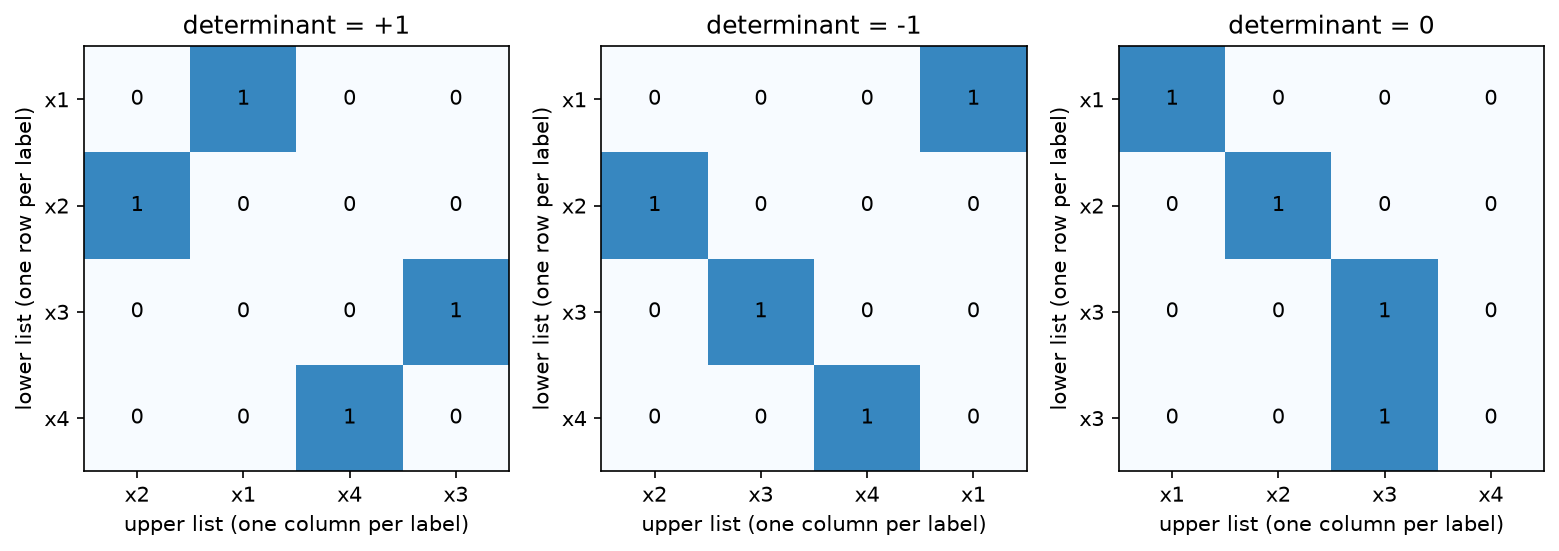

Figure 11a.1 saved as Revision/textbook/figures/11a_1_outer_delta_matrices.png
PASS the three drawn matrices have the determinants +1, -1 and 0


In [3]:
SHOWN = [  # (lower list, upper list) with labels 0..7 standing for x1..x8
    ((0, 1, 2, 3), (1, 0, 3, 2)),  # x2 x1 x4 x3: two exchanges, even
    ((0, 1, 2, 3), (1, 2, 3, 0)),  # x2 x3 x4 x1: a cycle of four, odd
    ((0, 1, 2, 2), (0, 1, 2, 3)),  # x3 twice in the lower list
]
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.9))
for ax, (lower, upper) in zip(axes, SHOWN):
    matrix = np.array(outer_delta(lower, upper))
    ax.imshow(matrix, cmap="Blues", vmin=0.0, vmax=1.5)  # 0 white, 1 blue
    for i in range(4):  # i: the row
        for j in range(4):  # j: the column
            ax.text(j, i, str(matrix[i, j]), ha="center", va="center")
    ax.set_xticks(range(4), [NAMES[label] for label in upper])  # column labels
    ax.set_yticks(range(4), [NAMES[label] for label in lower])  # row labels
    ax.set_xlabel("upper list (one column per label)")
    ax.set_ylabel("lower list (one row per label)")
    value = kdelta(lower, upper)
    ax.set_title(f"determinant = {value:+d}" if value else "determinant = 0")
    ax.grid(False)  # no grid lines across the squares
fig.tight_layout()  # no overlapping labels
save_figure(fig, "outer_delta_matrices",
            "The matrix Outer of delta for three pairs of index lists of length 4; "
            "row i belongs to the i-th lower label, column j to the j-th upper "
            "label, and the entry is 1 where the two labels are equal. Left: the "
            "upper list is the lower list with two exchanges, the matrix is a "
            "permutation matrix of an even permutation and its determinant is +1. "
            "Middle: a cycle of four labels, an odd permutation, determinant -1. "
            "Right: the label $x_3$ appears twice in the lower list, so two rows are "
            "equal and the column of $x_4$ is empty: determinant 0.")
check([kdelta(lower, upper) for lower, upper in SHOWN] == [1, -1, 0],
      "the three drawn matrices have the determinants +1, -1 and 0")

## 6. The rule behind GKD: the sign of a permutation

The next cell writes the rule of the theorem as the Python function `gkd`. It
follows the Rust function GKD of `Revision/gkd_lovelock/code/src/gkd.rs` step by
step:

1. It walks through the upper list and records in the dictionary `position` the
   place of every label; a label seen twice means two equal columns: value 0
   (case b).
2. It walks through the lower list and looks up the place of every label; a label
   that is not in the upper list means a row of zeros: value 0 (case c). The places
   form the list `sigma`.
3. If a place occurs twice in `sigma`, a label occurs twice in the lower list: value
   0 (case a).
4. Otherwise `sigma` is a permutation. The cell counts its inversions (pairs of
   places $i < j$ with `sigma[i] > sigma[j]`) and returns $+1$ for an even count and
   $-1$ for an odd count (case d).

The cell then checks that `gkd` and `kdelta` agree on the five examples.

In [4]:
def inversions(sigma):
    """The number of pairs of places i < j with sigma[i] > sigma[j]."""
    return sum(1 for i in range(len(sigma)) for j in range(i + 1, len(sigma))
               if sigma[i] > sigma[j])


def gkd(lower, upper):
    """The rule GKD (the Rust function GKD, written in Python): the sign of the
    permutation that carries the lower list into the upper list, or 0."""
    if len(lower) != len(upper):
        raise ValueError("gkd needs two index lists of the same length")
    position = {}  # label -> its place in the upper list
    for place, label in enumerate(upper):
        if label in position:
            return 0  # a label twice in the upper list: equal columns (case b)
        position[label] = place
    sigma = []  # sigma[i]: the place in the upper list of the i-th lower label
    for label in lower:
        if label not in position:
            return 0  # a lower label missing above: a row of zeros (case c)
        sigma.append(position[label])
    if len(set(sigma)) < len(sigma):
        return 0  # a label twice in the lower list: equal rows (case a)
    return 1 if inversions(sigma) % 2 == 0 else -1  # even +1, odd -1 (case d)


for lower, upper, stated in EXAMPLES:
    say(f"gkd({list(lower)}, {list(upper)}) = {gkd(lower, upper)}")
check(all(gkd(lower, upper) == kdelta(lower, upper) for lower, upper, _ in EXAMPLES),
      "gkd and kdelta agree on the five examples")

gkd([1, 2], [1, 2]) = 1
gkd([1, 2], [2, 1]) = -1
gkd([1, 1], [1, 1]) = 0
gkd([1, 2, 3], [2, 3, 1]) = 1
gkd([1, 2, 3], [1, 2, 4]) = 0
PASS gkd and kdelta agree on the five examples


The next cell draws all $3! = 6$ arrangements of the three labels $x_1, x_2, x_3$:
for each one the matrix Outer[delta, lower, upper] with the lower list
$(x_1, x_2, x_3)$, the permutation $\sigma$ (the places of $x_1, x_2, x_3$ in the
upper list, counted from 0 as Python counts), its number of inversions and its sign.
Three arrangements are even and three are odd, as the counting argument of section 4
says. The check confirms that the sign from the inversions equals the exact
determinant for all six.

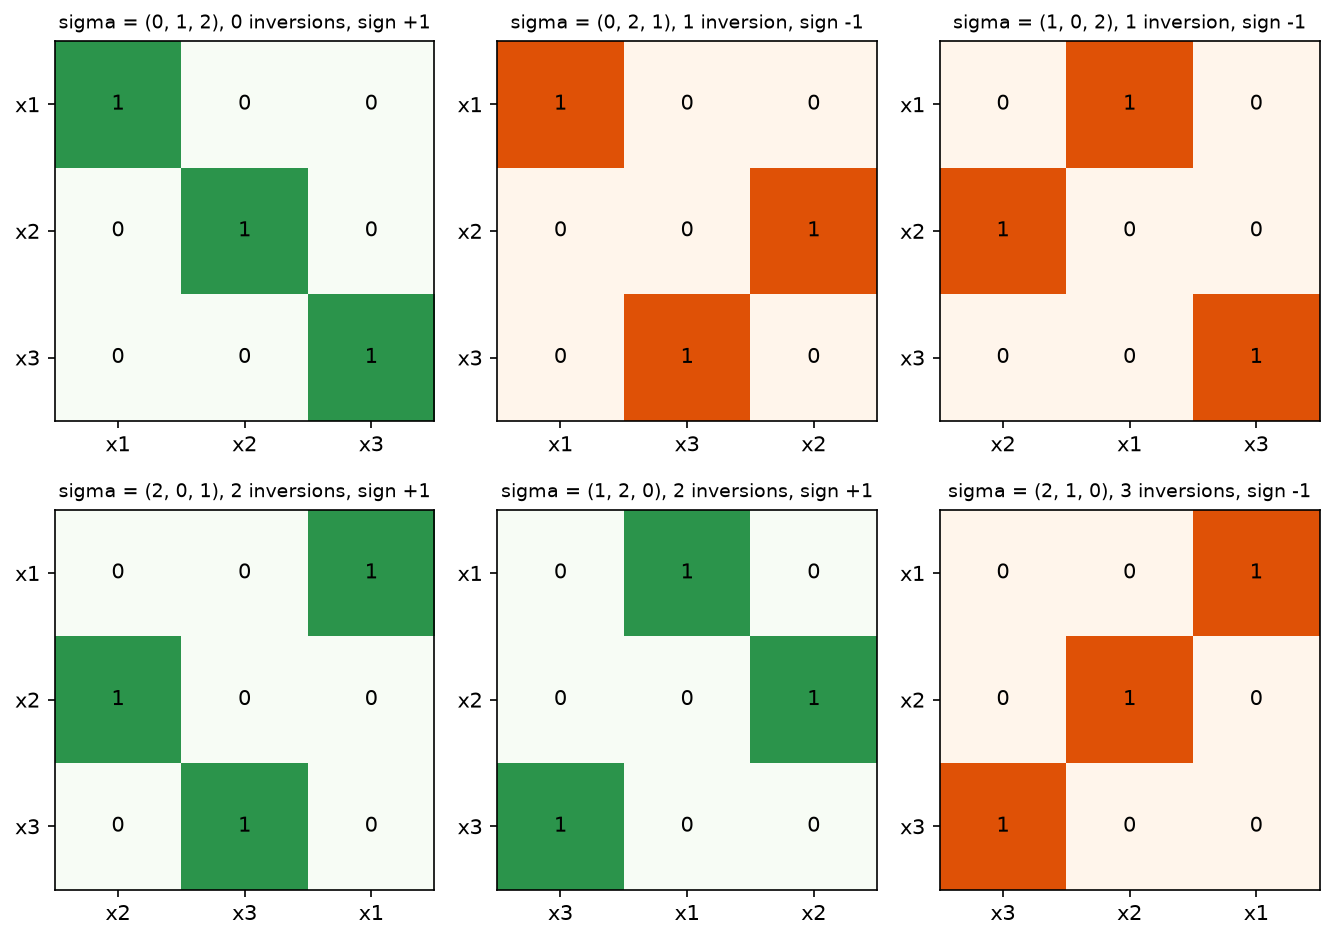

Figure 11a.2 saved as Revision/textbook/figures/11a_2_six_permutations.png
PASS the six arrangements of three labels: three even, three odd, sign = determinant


In [5]:
lower = (0, 1, 2)  # x1, x2, x3
fig, axes = plt.subplots(2, 3, figsize=(9.0, 6.4))
signs = []
for ax, upper in zip(axes.flat, itertools.permutations(lower)):
    matrix = np.array(outer_delta(lower, upper))
    sigma = [upper.index(label) for label in lower]  # places of x1, x2, x3 above
    sign = 1 if inversions(sigma) % 2 == 0 else -1
    signs.append((sign, kdelta(lower, upper)))
    ax.imshow(matrix, cmap="Greens" if sign > 0 else "Oranges", vmin=0.0, vmax=1.4)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, str(matrix[i, j]), ha="center", va="center")
    ax.set_xticks(range(3), [NAMES[label] for label in upper])
    ax.set_yticks(range(3), [NAMES[label] for label in lower])
    count = inversions(sigma)  # the number of inversions of sigma
    plural = "" if count == 1 else "s"  # 1 inversion, 2 inversions
    ax.set_title(f"sigma = {tuple(sigma)}, {count} inversion{plural}, "
                 f"sign {sign:+d}", fontsize=9)
    ax.grid(False)
fig.tight_layout()
save_figure(fig, "six_permutations",
            "All six arrangements of the labels $x_1, x_2, x_3$. Each panel shows "
            "the matrix Outer of delta with the lower list $(x_1, x_2, x_3)$ as rows "
            "and the arranged upper list as columns; the title gives the permutation "
            "$\\sigma$ (the place of each lower label in the upper list, counted from "
            "0), its number of inversions and its sign. Green panels are even "
            "permutations (sign +1), orange ones odd (sign -1): three of each, and "
            "each sign equals the determinant of the matrix.")
check(all(sign == det for sign, det in signs) and
      sorted(sign for sign, _ in signs) == [-1, -1, -1, 1, 1, 1],
      "the six arrangements of three labels: three even, three odd, sign = determinant")

## 7. Every pair of lists of length 1, 2 and 3

The next cell compares `gkd` with the literal determinant `kdelta` for EVERY pair of
index lists of length $p = 1, 2, 3$ over the eight labels: $8^{2p}$ pairs for each
$p$, that is $64 + 4096 + 262144 = 266304$ pairs. `itertools.product(range(8),
repeat=p)` produces all $8^p$ lists of length $p$ with entries $0, \dots, 7$. The
cell counts how often each value occurs and prints, for each $p$, the number of
pairs and the counts of $+1$, $-1$ and $0$. It takes a few seconds. At the end it
reads the Revision's Wolfram verification `wolfram-gkd-report.json`, whose checks
`gkd_equals_kdelta_exhaustive_length_1` to `_3` compared GKD with the literal
determinant on the same 266,304 pairs, and requires that they found no difference.

In [6]:
COUNTS = {}  # p -> {+1: count, -1: count, 0: count}
mismatches = 0  # pairs where gkd and the determinant differ
for p in (1, 2, 3):
    counts = {1: 0, -1: 0, 0: 0}
    for lower in itertools.product(range(8), repeat=p):  # all 8^p lower lists
        for upper in itertools.product(range(8), repeat=p):  # all 8^p upper lists
            value = gkd(lower, upper)
            if value != kdelta(lower, upper):
                mismatches += 1
            counts[value] += 1
    COUNTS[p] = counts
    say(f"p = {p}: {8 ** (2 * p):6d} pairs; value +1: {counts[1]:4d} times, "
        f"-1: {counts[-1]:4d} times, 0: {counts[0]:6d} times")
compared = sum(8 ** (2 * p) for p in (1, 2, 3))
report("pairs compared (all pairs of lengths 1, 2 and 3)", compared)
report("pairs where GKD and the determinant differ", mismatches)
report("different 0/1 matrices whose determinant sympy computed", len(DETERMINANTS))
wolfram_record = json.loads(repository_file(
    "Revision/gkd_lovelock/results/wolfram-gkd-report.json").read_text(
        encoding="utf-8"))
entries = [c for c in wolfram_record["checks"]
           if c["name"].startswith("gkd_equals_kdelta_exhaustive_length_")]
recorded_pairs = sum(int(re.search(r"all (\d+) pairs", e["detail"]).group(1))
                     for e in entries)  # the numbers of pairs the record names
check(mismatches == 0 and compared == 266304 and len(entries) == 3
      and all(e["verdict"] == "PASS" and "(0 mismatches;" in e["detail"]
              for e in entries) and recorded_pairs == 266304,
      "GKD equals the literal determinant for all 266304 pairs of lengths 1 to 3",
      record="Revision/gkd_lovelock/results/wolfram-gkd-report.json, checks "
             "gkd_equals_kdelta_exhaustive_length_1 to _3")

p = 1:     64 pairs; value +1:    8 times, -1:    0 times, 0:     56 times
p = 2:   4096 pairs; value +1:   56 times, -1:   56 times, 0:   3984 times
p = 3: 262144 pairs; value +1: 1008 times, -1: 1008 times, 0: 260128 times
RESULT pairs compared (all pairs of lengths 1, 2 and 3) = 266304
RESULT pairs where GKD and the determinant differ = 0
RESULT different 0/1 matrices whose determinant sympy computed = 145
PASS GKD equals the literal determinant for all 266304 pairs of lengths 1 to 3
     reproduces Revision/gkd_lovelock/results/wolfram-gkd-report.json, checks
    gkd_equals_kdelta_exhaustive_length_1 to _3


The next cell compares these counts with two things: the formula of section 4,
$N_{\ne 0}(p) = 8!/(8 - p)! \cdot p!$ with half of the nonzero values $+1$ and half
$-1$ for $p \ge 2$ (all $+1$ for $p = 1$), and the counts that the Revision's Wolfram
verification recorded in `wolfram-gkd-report.json` (its entry `measurements`,
`gkdComparison`, fields `plusOne`, `minusOne`, `zero`). `math.perm(8, p)` is
$8!/(8 - p)!$ and `math.factorial(p)` is $p!$.

In [7]:
def nonzero_pairs(p, n=8):
    """Pairs of lists of length p over n labels whose delta is not 0:
    n!/(n-p)! lower lists of different labels, times p! orders above."""
    return math.perm(n, p) * math.factorial(p)


def formula_counts(p):
    """{+1, -1, 0} -> count, from the formula of section 4."""
    nonzero = nonzero_pairs(p)
    plus = nonzero if p == 1 else nonzero // 2  # p = 1: only the identity
    return {1: plus, -1: nonzero - plus, 0: 8 ** (2 * p) - nonzero}


wolfram = json.loads(repository_file(
    "Revision/gkd_lovelock/results/wolfram-gkd-report.json").read_text(
        encoding="utf-8"))
for p in (1, 2, 3):
    recorded = [m for m in wolfram["measurements"]["gkdComparison"] if m["p"] == p][0]
    plus, minus, zero = recorded["plusOne"], recorded["minusOne"], recorded["zero"]
    say(f"p = {p}: formula {formula_counts(p)}, Wolfram record +1: {plus}, "
        f"-1: {minus}, 0: {zero}")
check(all(COUNTS[p] == formula_counts(p) for p in (1, 2, 3)),
      "the counts of +1, -1 and 0 equal the formula for p = 1, 2, 3")
check(all(COUNTS[p] == {1: m["plusOne"], -1: m["minusOne"], 0: m["zero"]}
          for p in (1, 2, 3)
          for m in wolfram["measurements"]["gkdComparison"] if m["p"] == p),
      "the counts equal those of the Wolfram verification",
      record="Revision/gkd_lovelock/results/wolfram-gkd-report.json, measurements "
             "gkdComparison, p = 1, 2, 3")

p = 1: formula {1: 8, -1: 0, 0: 56}, Wolfram record +1: 8, -1: 0, 0: 56
p = 2: formula {1: 56, -1: 56, 0: 3984}, Wolfram record +1: 56, -1: 56, 0: 3984
p = 3: formula {1: 1008, -1: 1008, 0: 260128}, Wolfram record +1: 1008, -1: 1008, 0:
    260128
PASS the counts of +1, -1 and 0 equal the formula for p = 1, 2, 3
PASS the counts equal those of the Wolfram verification
     reproduces Revision/gkd_lovelock/results/wolfram-gkd-report.json, measurements
    gkdComparison, p = 1, 2, 3


The next cell draws the value of GKD for all 4096 pairs of length 2 as one picture
of $64 \times 64$ squares. Row number $8 l_1 + l_2$ belongs to the lower list
$(l_1, l_2)$ and column number $8 u_1 + u_2$ to the upper list $(u_1, u_2)$ (so the
rows and columns run through $(x_1, x_1), (x_1, x_2), \dots, (x_8, x_8)$). A red
square is $+1$, a blue square $-1$, white is $0$. The red squares lie on the
diagonal (upper list = lower list), except at the 8 lists with $l_1 = l_2$; each
blue square is the mirror of a red one (the two labels exchanged).

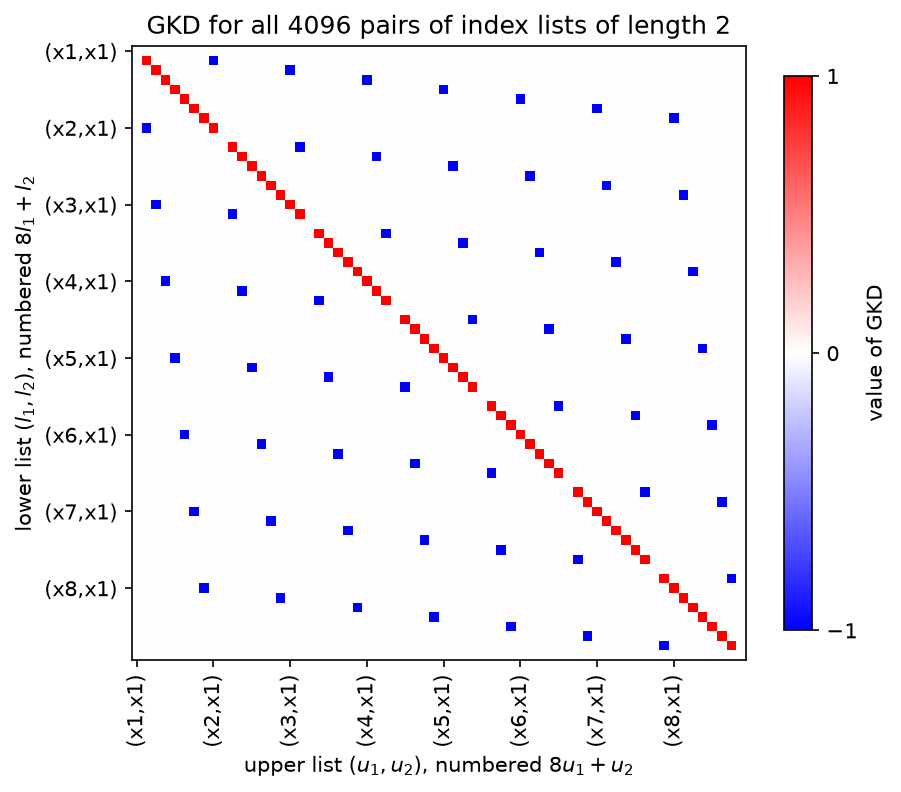

Figure 11a.3 saved as Revision/textbook/figures/11a_3_gkd_map_length_two.png
PASS length 2: 56 values +1, 56 values -1, and the picture is symmetric


In [8]:
pairs_of_labels = list(itertools.product(range(8), repeat=2))  # 64 lists (l1, l2)
grid = np.array([[gkd(lower, upper) for upper in pairs_of_labels]
                 for lower in pairs_of_labels])  # 64 x 64 values
fig, ax = plt.subplots(figsize=(6.6, 6.0))
picture = ax.imshow(grid, cmap="bwr", vmin=-1, vmax=1)  # blue -1, red +1
ticks = range(0, 64, 8)  # one tick at the start of each block of 8
ax.set_xticks(ticks, [f"({NAMES[t // 8]},x1)" for t in ticks], rotation=90)
ax.set_yticks(ticks, [f"({NAMES[t // 8]},x1)" for t in ticks])
ax.set_xlabel("upper list $(u_1, u_2)$, numbered $8 u_1 + u_2$")
ax.set_ylabel("lower list $(l_1, l_2)$, numbered $8 l_1 + l_2$")
ax.set_title("GKD for all 4096 pairs of index lists of length 2")
ax.grid(False)
fig.colorbar(picture, ax=ax, ticks=[-1, 0, 1], shrink=0.8, label="value of GKD")
save_figure(fig, "gkd_map_length_two",
            "The value of the generalized Kronecker delta for all 4096 pairs of "
            "index lists of length 2 over the labels $x_1, \\dots, x_8$; row "
            "$8 l_1 + l_2$ is the lower list $(l_1, l_2)$ and column $8 u_1 + u_2$ "
            "the upper list, counted from 0. Red squares are +1, blue squares -1, "
            "white squares 0. There are 56 red squares on the diagonal, where the "
            "upper list equals the lower list (the 8 lists with two equal labels "
            "are white), and 56 blue squares at the mirrored places, where the two "
            "labels are exchanged; the other 3984 values are 0.")
check(int((grid == 1).sum()) == 56 and int((grid == -1).sum()) == 56
      and np.array_equal(grid, grid.T),
      "length 2: 56 values +1, 56 values -1, and the picture is symmetric")

The next cell draws the three counts for each length $p = 1, 2, 3, 4$ as bars on a
logarithmic vertical axis (each step of the axis is a factor of 10, so that 8 and
16 million fit into one picture). For $p = 1, 2, 3$ the bars are the counts measured
above; for $p = 4$ they come from the formula (the Rust self-test of section 10
compares all 16,777,216 pairs of length 4 but prints only the number of
disagreements). A count of zero cannot be drawn on a logarithmic axis; it is marked
"none".

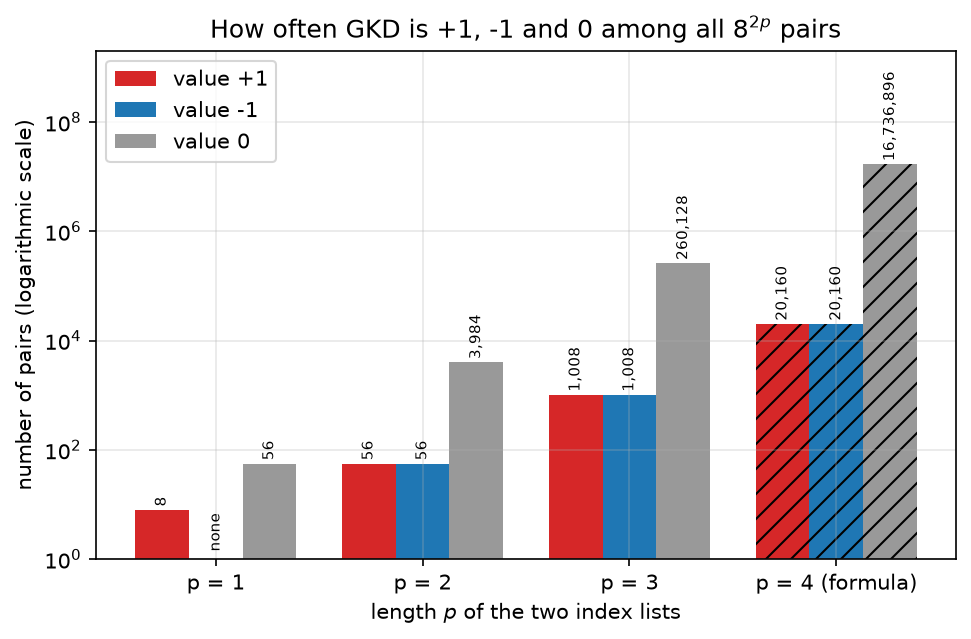

Figure 11a.4 saved as Revision/textbook/figures/11a_4_value_counts.png
PASS length 4: 20160 values +1, 20160 values -1 and 16736896 zeros (formula)


In [9]:
fig, ax = plt.subplots(figsize=(7.4, 4.4))
width = 0.26  # the width of one bar
for shift, value, colour, name in ((-width, 1, "tab:red", "value +1"),
                                   (0.0, -1, "tab:blue", "value -1"),
                                   (width, 0, "0.6", "value 0")):
    heights = [COUNTS[p][value] if p < 4 else formula_counts(4)[value]
               for p in (1, 2, 3, 4)]
    bars = ax.bar([p + shift for p in (1, 2, 3, 4)], heights, width, color=colour,
                  label=name, hatch=None)
    bars[3].set_hatch("//")  # p = 4: from the formula
    for p, height in zip((1, 2, 3, 4), heights):
        ax.text(p + shift, max(height, 1.2) * 1.15, f"{height:,}" if height else
                "none", ha="center", va="bottom", fontsize=7, rotation=90)
ax.set_yscale("log")  # a logarithmic vertical axis
ax.set_ylim(1.0, 2e9)
ax.set_xticks([1, 2, 3, 4], ["p = 1", "p = 2", "p = 3", "p = 4 (formula)"])
ax.set_xlabel("length $p$ of the two index lists")
ax.set_ylabel("number of pairs (logarithmic scale)")
ax.set_title("How often GKD is +1, -1 and 0 among all $8^{2p}$ pairs")
ax.legend(loc="upper left")
save_figure(fig, "value_counts",
            "The number of pairs of index lists of length $p$ over the eight labels "
            "whose generalized Kronecker delta is +1 (red), -1 (blue) and 0 (grey), "
            "for $p = 1$ to $4$, on a logarithmic vertical axis; the hatched bars of "
            "$p = 4$ come from the formula $N = 8!/(8 - p)! \\cdot p!$ for the "
            "nonzero values, the others are counted by the notebook. The value 0 "
            "dominates more and more: for $p = 4$ only 40,320 of the 16,777,216 "
            "pairs are nonzero, half of them +1 and half -1.")
check(formula_counts(4) == {1: 20160, -1: 20160, 0: 16736896},
      "length 4: 20160 values +1, 20160 values -1 and 16736896 zeros (formula)")

## 8. Longer lists: random pairs and the pigeonhole principle

For $p = 4$ to $9$ there are too many pairs to test them all in Python ($8^{18}$ for
$p = 9$). The next cell tests 2,000 pseudo-random pairs of each length. The
generator `np.random.default_rng(12345)` makes the same numbers on every computer.
For an even sample number `s` the lower list is the upper list rearranged in random
order (`rng.permutation(p)` is a random arrangement of the places), so the delta is
nonzero whenever the upper list has $p$ different labels; for an odd `s` the lower
list is a second, independent random list, and the delta is almost always zero. The
cell counts the disagreements between `gkd` and `kdelta` and the number of nonzero
values. Because a list of 9 labels from 8 must repeat a label, every value of
length 9 must be zero. The cell takes a few seconds: sympy computes the
determinants of about ten thousand new matrices of sizes $4 \times 4$ to $9 \times 9$
(the cell prints how many different matrices `kdelta` has met so far).

In [10]:
rng = np.random.default_rng(12345)  # pseudo-random numbers with a fixed seed
SAMPLES = 2000  # pairs per length p
python_nonzero = {}  # p -> number of nonzero values among the samples
random_mismatches = 0
for p in range(4, 10):
    nonzero = 0
    for s in range(SAMPLES):
        upper = [int(v) for v in rng.integers(0, 8, size=p)]  # p labels from 0..7
        if s % 2 == 0:  # even s: the lower list is the upper list rearranged
            lower = [upper[i] for i in rng.permutation(p)]
        else:  # odd s: an independent random lower list
            lower = [int(v) for v in rng.integers(0, 8, size=p)]
        value = gkd(lower, upper)
        nonzero += value != 0  # True counts as 1, False as 0
        random_mismatches += value != kdelta(lower, upper)
    python_nonzero[p] = nonzero
    say(f"p = {p}: {SAMPLES} random pairs, {nonzero:4d} nonzero values")
report("random pairs compared (lengths 4 to 9)", 6 * SAMPLES)
report("random pairs where GKD and the determinant differ", random_mismatches)
report("different 0/1 matrices whose determinant sympy computed (so far)",
       len(DETERMINANTS))
check(random_mismatches == 0,
      "GKD equals the literal determinant for 12000 random pairs of lengths 4 to 9")
check(python_nonzero[9] == 0,
      "every delta with 9 indices in 8 dimensions is 0 (pigeonhole)",
      record="Revision/gkd_lovelock/results/python-lovelock-report.json, "
             "check gkd_nine_indices_in_eight_dimensions_vanish")

p = 4: 2000 random pairs,  394 nonzero values
p = 5: 2000 random pairs,  186 nonzero values
p = 6: 2000 random pairs,   82 nonzero values
p = 7: 2000 random pairs,   24 nonzero values
p = 8: 2000 random pairs,    3 nonzero values
p = 9: 2000 random pairs,    0 nonzero values
RESULT random pairs compared (lengths 4 to 9) = 12000
RESULT random pairs where GKD and the determinant differ = 0
RESULT different 0/1 matrices whose determinant sympy computed (so far) = 10097
PASS GKD equals the literal determinant for 12000 random pairs of lengths 4 to 9
PASS every delta with 9 indices in 8 dimensions is 0 (pigeonhole)
     reproduces Revision/gkd_lovelock/results/python-lovelock-report.json, check
    gkd_nine_indices_in_eight_dimensions_vanish


How many nonzero values should we expect? In an even sample the delta is nonzero
exactly when the $p$ random labels of the upper list are all different. Each label
is one of 8 with equal chance, so the chance that $p$ labels are all different is

$$r_p = \frac{8}{8} \cdot \frac{7}{8} \cdots \frac{8 - p + 1}{8}
      = \frac{8!}{(8 - p)!\, 8^p}$$

(the second label must avoid the first, the third the first two, and so on; this is
the "birthday problem" with 8 possible birthdays). In an odd sample the chance is
$q_p = N_{\ne 0}(p)/8^{2p}$, tiny for $p \ge 4$. With 1,000 samples of each kind the
expected number of nonzero values is $1000\,(r_p + q_p)$, and the usual random
scatter of such a count (its standard deviation) is
$\sqrt{1000\, r_p (1 - r_p) + 1000\, q_p (1 - q_p)}$. The next cell checks that every
count lies within 5 standard deviations of its expectation (a count further away
would happen by chance less than once in a million times).

In [11]:
def all_different(p, n=8):
    """The chance r_p that p random labels out of n are all different."""
    return math.perm(n, p) / n ** p if p <= n else 0.0


def expected_nonzero(p, half):
    """Expected number of nonzero deltas and its standard deviation, for `half`
    rearranged pairs and `half` independent pairs of length p."""
    r = all_different(p)
    q = nonzero_pairs(p) / 8 ** (2 * p) if p <= 8 else 0.0
    mean = half * (r + q)
    spread = math.sqrt(half * r * (1 - r) + half * q * (1 - q))
    return mean, spread


within = True
for p in range(4, 10):
    mean, spread = expected_nonzero(p, SAMPLES // 2)
    distance = abs(python_nonzero[p] - mean) / spread if spread > 0 else 0.0
    say(f"p = {p}: counted {python_nonzero[p]:4d}, expected {mean:7.1f} "
        f"+- {spread:5.1f}  ({distance:.2f} standard deviations away)")
    within = within and (distance < 5.0 if spread > 0 else python_nonzero[p] == 0)
check(within, "the Python counts of nonzero values agree with the birthday formula")

p = 4: counted  394, expected   412.6 +-  15.6  (1.19 standard deviations away)
p = 5: counted  186, expected   205.8 +-  12.8  (1.55 standard deviations away)
p = 6: counted   82, expected    77.1 +-   8.4  (0.58 standard deviations away)
p = 7: counted   24, expected    19.3 +-   4.3  (1.09 standard deviations away)
p = 8: counted    3, expected     2.4 +-   1.6  (0.38 standard deviations away)
p = 9: counted    0, expected     0.0 +-   0.0  (0.00 standard deviations away)
PASS the Python counts of nonzero values agree with the birthday formula


## 9. Why the rule is needed: the cost of the determinant

The Leibniz formula adds $p!$ products of $p$ entries; the rule GKD makes
$p(p - 1)/2$ comparisons of places. The next cell prints both numbers for
$p = 1, \dots, 9$, together with the number $8^{2p}$ of all pairs of lists of length
$p$, and draws them. Then it MEASURES the difference: it times 200 evaluations of
`gkd` and 200 exact determinants of sympy (without the memory of `kdelta`) on the
same pairs of lists of length 7 and checks that the rule is more than ten times
faster. The measured times differ from computer to computer and from run to run, so
they are not printed (the printed output of a notebook of this book is the same on
every run); only the result of the comparison is.

p = 1: Leibniz products      1, comparisons of GKD  0, pairs of lists 6.400e+01
p = 2: Leibniz products      2, comparisons of GKD  1, pairs of lists 4.096e+03
p = 3: Leibniz products      6, comparisons of GKD  3, pairs of lists 2.621e+05
p = 4: Leibniz products     24, comparisons of GKD  6, pairs of lists 1.678e+07
p = 5: Leibniz products    120, comparisons of GKD 10, pairs of lists 1.074e+09
p = 6: Leibniz products    720, comparisons of GKD 15, pairs of lists 6.872e+10
p = 7: Leibniz products   5040, comparisons of GKD 21, pairs of lists 4.398e+12
p = 8: Leibniz products  40320, comparisons of GKD 28, pairs of lists 2.815e+14
p = 9: Leibniz products 362880, comparisons of GKD 36, pairs of lists 1.801e+16


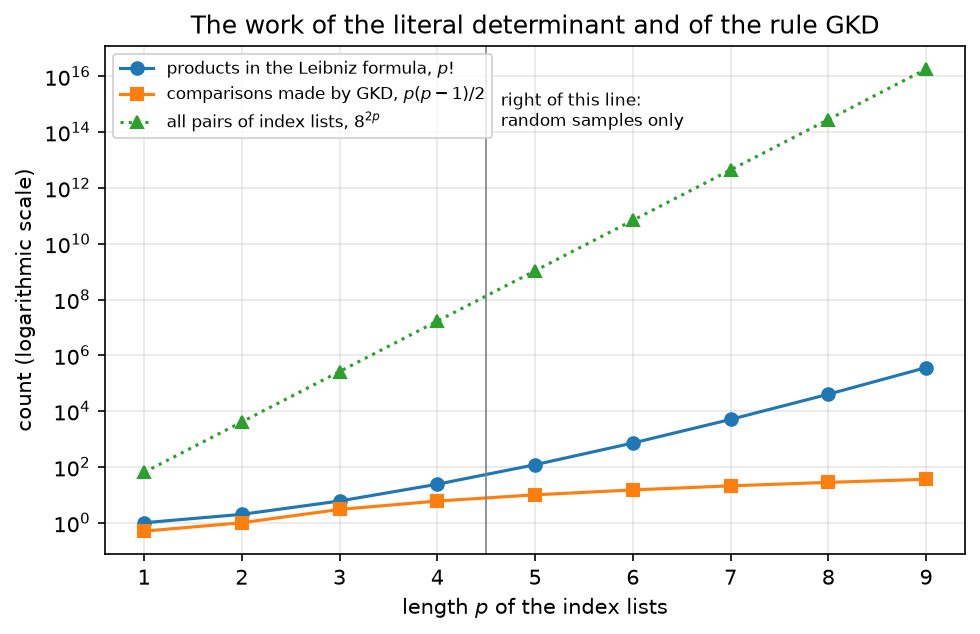

Figure 11a.5 saved as Revision/textbook/figures/11a_5_cost_of_the_determinant.png
PASS 200 pairs of length 7: the rule and sympy's determinant agree
PASS the rule GKD is more than ten times faster than the determinant (p = 7)


In [12]:
lengths = list(range(1, 10))
leibniz_terms = [math.factorial(p) for p in lengths]  # products in the formula
comparisons = [p * (p - 1) // 2 for p in lengths]  # comparisons of the rule
all_pairs = [8 ** (2 * p) for p in lengths]  # all pairs of lists of length p
for p, terms, compare, total in zip(lengths, leibniz_terms, comparisons, all_pairs):
    say(f"p = {p}: Leibniz products {terms:6d}, comparisons of GKD {compare:2d}, "
        f"pairs of lists {total:.3e}")

fig, ax = plt.subplots(figsize=(7.4, 4.4))
ax.semilogy(lengths, leibniz_terms, "o-", label="products in the Leibniz formula, $p!$")
ax.semilogy(lengths, [max(c, 0.5) for c in comparisons], "s-",
            label="comparisons made by GKD, $p(p-1)/2$")
ax.semilogy(lengths, all_pairs, "^:", label="all pairs of index lists, $8^{2p}$")
ax.axvline(4.5, color="0.5", lw=0.8)  # where exhaustive testing ends
ax.text(4.65, 3e15, "right of this line:\nrandom samples only", fontsize=8,
        va="top")
ax.set_xlabel("length $p$ of the index lists")
ax.set_ylabel("count (logarithmic scale)")
ax.set_title("The work of the literal determinant and of the rule GKD")
ax.legend(loc="upper left", fontsize=8)
save_figure(fig, "cost_of_the_determinant",
            "Work per evaluation of the generalized Kronecker delta for index lists "
            "of length $p$: the Leibniz formula of the determinant adds $p!$ "
            "products (circles), the rule GKD makes $p(p-1)/2$ comparisons "
            "(squares; drawn at 0.5 for $p = 1$, where it makes none); the "
            "triangles count all $8^{2p}$ pairs of index lists over eight labels. "
            "The vertical axis is logarithmic. For $p = 9$ the formula needs "
            "362,880 products against 36 comparisons, and the number of pairs "
            "grows so fast that only $p \\le 4$ can be tested exhaustively.")

timing_rng = np.random.default_rng(7)
timing_pairs = []
for _ in range(200):
    upper = [int(v) for v in timing_rng.permutation(8)[:7]]  # 7 different labels
    lower = [upper[i] for i in timing_rng.permutation(7)]  # the same, rearranged
    timing_pairs.append((lower, upper))
start = time.perf_counter()
rule_values = [gkd(lower, upper) for lower, upper in timing_pairs]
rule_seconds = time.perf_counter() - start
start = time.perf_counter()
determinant_values = [int(sp.Matrix(outer_delta(lower, upper)).det())
                      for lower, upper in timing_pairs]  # no memory: all computed
determinant_seconds = time.perf_counter() - start
check(rule_values == determinant_values,
      "200 pairs of length 7: the rule and sympy's determinant agree")
check(determinant_seconds > 10 * rule_seconds,
      "the rule GKD is more than ten times faster than the determinant (p = 7)")

## 10. The Rust program: the self-test of GKD

The Revision computes the Lovelock tensors with the Rust program `lovelock_gkd`
(crate `Revision/gkd_lovelock/code`). Its function GKD is the rule of section 6, and
its function `kdelta_det` is the literal Leibniz determinant of
Outer[delta, lower, upper] (it runs through all $p!$ permutations with Heap's
method, which changes one permutation into the next by one exchange). Its command
`gkd-selftest` compares the two:

- for $p = 1, 2, 3, 4$ (the option `--exhaustive-max 4`), EVERY pair of lists of
  length $p$ over the 8 labels: $64 + 4096 + 262144 + 16777216$ pairs;
- for $p = 5, \dots, 9$, 200,000 pseudo-random pairs each from its own fixed
  generator (xorshift64*), half of them rearrangements (Fisher-Yates shuffle) and
  half independent lists, as in section 8.

It writes the result to the file `gkd-selftest.json` in the folder given by
`--output`, without any time in it, so the file is the same on every run. The
committed Revision record `Revision/gkd_lovelock/results/gkd-selftest.json` was
written by the same command.

The next cell builds the program with cargo, through the helper `rust_program` of the
set-up cell, which runs `cargo build --release` for the crate and returns the path of
the program file (`lovelock_gkd.exe` on Windows). When the program file is missing,
cargo compiles it: on the computer that built the book this took 4 seconds; a slow
computer may need up to a minute. When the program is up to date, cargo only checks
that and needs about a second. The crate has no dependencies, so cargo downloads
nothing.

In [13]:
program = rust_program("Revision/gkd_lovelock/code/Cargo.toml", "lovelock_gkd")

Rust program lovelock_gkd is built and ready.


The next cell runs `lovelock_gkd gkd-selftest --exhaustive-max 4 --output FOLDER`.
FOLDER is `Revision/gkd_lovelock/code/target/textbook_11a`, inside the crate's build
folder `target`, which cargo has just made and which git ignores; so the run adds no
file to the repository. **This cell takes several minutes** (on the computer on
which the book was built, between 7 and 13 minutes in different runs, depending on
how busy the computer was). Timed part by part on that computer, on a busy day: the
exhaustive tests of lengths 1 to 4 took about 10 seconds, the random tests of
lengths 5, 6, 7 and 8 about 0.3, 1.6, 11 and 79 seconds, and the 200,000
determinants of $9 \times 9$ matrices, each a sum of $9! = 362880$ products, about
640 seconds: more than four fifths of the whole. From one length to the next the
work of one literal determinant grows by the factor $p$ (from $(p-1)!$ to $p!$
products), and the measured times of lengths 7, 8 and 9 grow by about 7, 7 and 8.

`subprocess.run([...], capture_output=True, text=True)` runs the program and
collects what it prints. The program prints one line per length, such as
`PASS - GKD vs literal ..., all 64 pairs of index lists of length 1 ...: 0
mismatches`, and a last line with its run time. The cell reads the numbers out of
these lines with regular expressions (`re.search`) and prints them as a table,
without the run time (it differs from run to run). Then it checks the exit status
of the program (0 means success) and compares the written file with the Revision
record byte for byte.

In [14]:
OUT_FOLDER = REPO / "Revision" / "gkd_lovelock" / "code" / "target" / "textbook_11a"
completed = subprocess.run(
    [str(program), "gkd-selftest", "--exhaustive-max", "4", "--output",
     str(OUT_FOLDER)],
    capture_output=True, text=True, encoding="utf-8", errors="replace")
say("The Rust self-test printed (as a table; its run time is left out):")
rust_rows = {}  # p -> (mode, pairs, nonzero or None, mismatches)
for line in completed.stdout.splitlines():
    found = re.search(r"all (\d+) pairs of index lists of length (\d+) .*: (\d+) "
                      r"mismatches", line)
    if found:  # an exhaustive length
        pairs, p, bad = (int(v) for v in found.groups())
        rust_rows[p] = ("exhaustive", pairs, None, bad)
    found = re.search(r"(\d+) pseudo-random pairs of length (\d+) \((\d+) nonzero\)"
                      r": (\d+) mismatches", line)
    if found:  # a random length
        pairs, p, nonzero, bad = (int(v) for v in found.groups())
        rust_rows[p] = ("random", pairs, nonzero, bad)
for p, (mode, pairs, nonzero, bad) in sorted(rust_rows.items()):
    extra = "" if nonzero is None else f", {nonzero:6d} nonzero"
    say(f"  p = {p}: {mode:10s} {pairs:9d} pairs{extra}; disagreements: {bad}")
check(completed.returncode == 0 and "gkd-selftest: SUCCESS" in completed.stdout,
      "the Rust program lovelock_gkd gkd-selftest ended with SUCCESS")
check(sorted(rust_rows) == list(range(1, 10))
      and all(row[3] == 0 for row in rust_rows.values())
      and rust_rows[4][:2] == ("exhaustive", 16777216),
      "Rust: GKD equals the literal determinant for every tested pair, p = 1 to 9")
written = (OUT_FOLDER / "gkd-selftest.json").read_bytes()
stored = repository_file("Revision/gkd_lovelock/results/gkd-selftest.json").read_bytes()
check(written == stored,
      "the program wrote gkd-selftest.json equal to the Revision record byte for byte",
      record="Revision/gkd_lovelock/results/gkd-selftest.json (the whole file)")

The Rust self-test printed (as a table; its run time is left out):
  p = 1: exhaustive        64 pairs; disagreements: 0
  p = 2: exhaustive      4096 pairs; disagreements: 0
  p = 3: exhaustive    262144 pairs; disagreements: 0
  p = 4: exhaustive  16777216 pairs; disagreements: 0
  p = 5: random        200000 pairs,  20538 nonzero; disagreements: 0
  p = 6: random        200000 pairs,   7812 nonzero; disagreements: 0
  p = 7: random        200000 pairs,   1949 nonzero; disagreements: 0
  p = 8: random        200000 pairs,    244 nonzero; disagreements: 0
  p = 9: random        200000 pairs,      0 nonzero; disagreements: 0
PASS the Rust program lovelock_gkd gkd-selftest ended with SUCCESS
PASS Rust: GKD equals the literal determinant for every tested pair, p = 1 to 9
PASS the program wrote gkd-selftest.json equal to the Revision record byte for byte
     reproduces Revision/gkd_lovelock/results/gkd-selftest.json (the whole file)


The file just compared is now read as JSON (a text format of names and numbers),
and its numbers are compared with the birthday formula of section 8. In the
program's random samples one half are rearrangements and one half independent lists,
100,000 each, so the expected number of nonzero values of length $p$ is
$100000\,(r_p + q_p)$, with the standard deviation of section 8. The next cell checks
that every count lies within 5 standard deviations of its expectation, and that the
count of length 9 is exactly 0. Then it draws the chance $r_p$ that $p$ random
labels out of 8 are all different, with the measured fractions: the number of
nonzero values found among ALL the samples of one length, divided by the number of
rearranged samples (1,000 in the Python test of section 8, 100,000 in the Rust
test). This fraction should be close to $r_p + q_p$; the independent pairs add the
small chance $q_p$, which is at most $0.0025$ (for $p = 4$, $q_4 = 40320/8^8$) and
invisible on the logarithmic axis.

Rust p = 5: counted  20538, expected  20582.9 +-  128.0  (0.35 standard deviations away)
Rust p = 6: counted   7812, expected   7711.6 +-   84.4  (1.19 standard deviations away)
Rust p = 7: counted   1949, expected   1927.2 +-   43.5  (0.50 standard deviations away)
Rust p = 8: counted    244, expected    240.9 +-   15.5  (0.20 standard deviations away)
Rust p = 9: counted      0, expected      0.0 +-    0.0  (0.00 standard deviations away)
PASS the Rust counts of nonzero values agree with the birthday formula


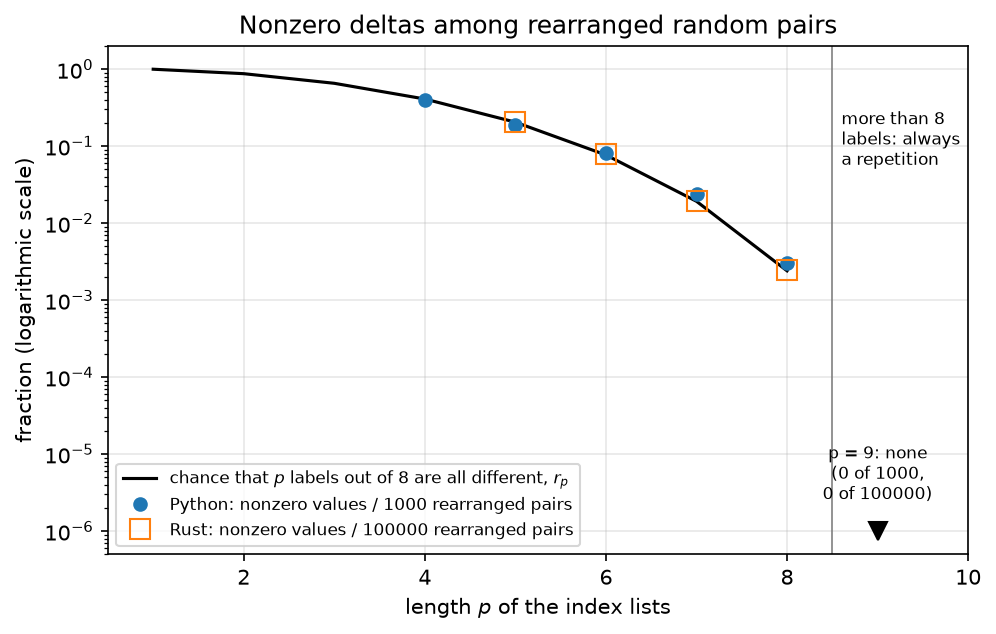

Figure 11a.6 saved as Revision/textbook/figures/11a_6_all_labels_different.png


In [15]:
selftest = json.loads(written.decode("utf-8"))
rust_nonzero = {row["p"]: row["nonzero"] for row in selftest["results"]
                if row["mode"] == "random"}
agree = True
for p, nonzero in sorted(rust_nonzero.items()):
    mean, spread = expected_nonzero(p, 100000)
    distance = abs(nonzero - mean) / spread if spread > 0 else 0.0
    say(f"Rust p = {p}: counted {nonzero:6d}, expected {mean:8.1f} +- {spread:6.1f}"
        f"  ({distance:.2f} standard deviations away)")
    agree = agree and (distance < 5.0 if spread > 0 else nonzero == 0)
check(selftest["verdict"] == "SUCCESS" and agree and rust_nonzero[9] == 0,
      "the Rust counts of nonzero values agree with the birthday formula")

lengths_1_to_8 = np.arange(1, 9)  # r_p is drawn where it is not zero
fig, ax = plt.subplots(figsize=(7.4, 4.4))
ax.semilogy(lengths_1_to_8, [all_different(p) for p in lengths_1_to_8], "k-",
            label="chance that $p$ labels out of 8 are all different, $r_p$")
python_points = [p for p in python_nonzero if python_nonzero[p] > 0]
ax.semilogy(python_points, [python_nonzero[p] / (SAMPLES // 2)
                            for p in python_points], "o",
            label="Python: nonzero values / 1000 rearranged pairs")
rust_points = [p for p in rust_nonzero if rust_nonzero[p] > 0]
ax.semilogy(rust_points, [rust_nonzero[p] / 100000 for p in rust_points], "s",
            fillstyle="none", markersize=10,
            label="Rust: nonzero values / 100000 rearranged pairs")
ax.plot([9], [1e-6], "v", color="black", markersize=9)  # marks the zeros of p = 9
ax.text(9.0, 2.2e-6, "p = 9: none\n(0 of 1000,\n0 of 100000)", fontsize=8,
        ha="center", va="bottom")
ax.axvline(8.5, color="0.5", lw=0.8)
ax.text(8.6, 0.3, "more than 8\nlabels: always\na repetition", fontsize=8, va="top")
ax.set_xlim(0.5, 10.0)
ax.set_ylim(5e-7, 2.0)
ax.set_xlabel("length $p$ of the index lists")
ax.set_ylabel("fraction (logarithmic scale)")
ax.set_title("Nonzero deltas among rearranged random pairs")
ax.legend(loc="lower left", fontsize=8)
save_figure(fig, "all_labels_different",
            "The chance $r_p = 8!/((8 - p)!\\, 8^p)$ that $p$ random labels out of "
            "eight are all different (line), which is the chance that a rearranged "
            "random pair of index lists has a nonzero generalized Kronecker delta, "
            "with the measured fractions: the nonzero values found among all the "
            "samples of one length divided by the number of rearranged samples, "
            "for the Python samples of this notebook (dots) and the Rust self-test "
            "(open squares); the independent samples add at most 0.0025. The "
            "vertical axis is logarithmic. The measured points follow the formula. "
            "For $p = 9$ no list can have nine "
            "different labels, so the chance and both measured fractions are 0, "
            "which a logarithmic axis cannot show; the black triangle at the "
            "bottom edge marks them.")

## 11. The Revision records quoted in this notebook

This notebook quotes check names and numbers from five Revision records. Two of them
were already compared in full: the self-test record `gkd-selftest.json` (byte for
byte, section 10) and the value counts of `wolfram-gkd-report.json` (section 7). The
next cell reads the records once more and checks the rest of what the text quotes,
so that a later change of a record cannot pass unnoticed:

- every check quoted from the sympy verification `python-lovelock-report.json` and
  from the Wolfram verification `wolfram-gkd-report.json` is present in the record
  with the verdict PASS;
- the record `PROVENANCE_OF_THE_COMPUTATION.md` contains the author's definition as
  quoted in section 4 (the part after the name k$\delta$, which is written with a
  Greek letter there);
- the counter `gkdCalls` of the order-3 sum in `lovelock-report.json` is 495,360, the
  number quoted in section 4.

The function `verdicts(path)` returns, for one report, a dictionary from the name of
each check to its verdict. The reports store their checks in one of two forms: a
list of entries, each with a `name` and a `verdict`, or a dictionary from the name to
an entry whose field `passed` is true or false; the function reads both.

In [16]:
def verdicts(path):
    """{check name: "PASS" or "FAIL"} of the Revision report at `path`."""
    data = json.loads(repository_file(path).read_text(encoding="utf-8"))
    checks = data["checks"]
    if isinstance(checks, dict):  # name -> {"passed": true or false, ...}
        return {name: "PASS" if entry["passed"] else "FAIL"
                for name, entry in checks.items()}
    return {entry["name"]: entry["verdict"] for entry in checks}  # a list of entries


RECORDS = "Revision/gkd_lovelock/results"  # the folder of the Revision records
QUOTED = {  # report -> the checks that this notebook quotes from it
    "python-lovelock-report.json": [
        "gkd_examples", "gkd_literal_equals_cofactor_expansion",
        "gkd_nine_indices_in_eight_dimensions_vanish"],
    "wolfram-gkd-report.json": [
        "gkd_equals_kdelta_exhaustive_length_1",
        "gkd_equals_kdelta_exhaustive_length_2",
        "gkd_equals_kdelta_exhaustive_length_3"],
}
for report_name, names in QUOTED.items():
    found = verdicts(f"{RECORDS}/{report_name}")
    for name in names:
        say(f"{report_name}: {name} {found.get(name, 'MISSING')}")
    check(all(found.get(name) == "PASS" for name in names),
          f"the {len(names)} checks quoted from {report_name} are there and PASS",
          record=f"{RECORDS}/{report_name}, checks " + ", ".join(names))
provenance = repository_file(
    f"{RECORDS}/PROVENANCE_OF_THE_COMPUTATION.md").read_text(encoding="utf-8")
definition = ("[lower_, upper_] /; Length[lower] == Length[upper] := "
              "Det[Outer[delta, lower, upper]]")  # after the name of the delta
check(definition in provenance,
      "the record quotes the author's definition as section 4 of this notebook "
      "does",
      record=f"{RECORDS}/PROVENANCE_OF_THE_COMPUTATION.md")
order_three = [row for row in json.loads(repository_file(
    f"{RECORDS}/lovelock-report.json").read_text(encoding="utf-8"))["counters"]
    if row["k"] == 3][0]
report("GKD calls of the order-3 Lovelock sum (record)", order_three["gkdCalls"])
check(order_three["gkdCalls"] == 495360,
      "the order-3 Lovelock sum calls GKD 495360 times, as section 4 of this "
      "notebook says",
      record=f"{RECORDS}/lovelock-report.json, counters, k = 3, gkdCalls")

python-lovelock-report.json: gkd_examples PASS
python-lovelock-report.json: gkd_literal_equals_cofactor_expansion PASS
python-lovelock-report.json: gkd_nine_indices_in_eight_dimensions_vanish PASS
PASS the 3 checks quoted from python-lovelock-report.json are there and PASS
     reproduces Revision/gkd_lovelock/results/python-lovelock-report.json, checks
    gkd_examples, gkd_literal_equals_cofactor_expansion,
    gkd_nine_indices_in_eight_dimensions_vanish
wolfram-gkd-report.json: gkd_equals_kdelta_exhaustive_length_1 PASS
wolfram-gkd-report.json: gkd_equals_kdelta_exhaustive_length_2 PASS
wolfram-gkd-report.json: gkd_equals_kdelta_exhaustive_length_3 PASS
PASS the 3 checks quoted from wolfram-gkd-report.json are there and PASS
     reproduces Revision/gkd_lovelock/results/wolfram-gkd-report.json, checks
    gkd_equals_kdelta_exhaustive_length_1, gkd_equals_kdelta_exhaustive_length_2,
    gkd_equals_kdelta_exhaustive_length_3
PASS the record quotes the author's definition as section 4 

The last cell checks that all six figure files exist in the folder
`Revision/textbook/figures` and prints the number of checks that passed.

In [17]:
figure_files = [f"11a_{k}_{name}.png" for k, name in enumerate(
    ["outer_delta_matrices", "six_permutations", "gkd_map_length_two",
     "value_counts", "cost_of_the_determinant", "all_labels_different"], 1)]
check(all(output_file(f"{FIGURE_FOLDER}/{name}").is_file() for name in figure_files),
      "all six figure files of the notebook exist")
all_checks_passed()

PASS all six figure files of the notebook exist
ALL 24 CHECKS PASSED (notebook 11a)


## 12. What this notebook showed

- The author's generalized Kronecker delta, the determinant of the 0/1 matrix
  Outer[delta, lower, upper], is $+1$, $-1$ or $0$: it is zero when a label repeats
  in either list or a lower label is missing above, and otherwise it is the sign of
  the permutation that carries the lower list into the upper list (PROVED in
  section 4).
- The Python rule `gkd` and the literal determinant agree on all 266,304 pairs of
  lengths 1 to 3 and on 12,000 random pairs of lengths 4 to 9 (COMPUTED). The counts
  of the values (8; 56 and 56; 1008 and 1008 nonzero values for $p = 1, 2, 3$) follow
  the formula $8!/(8 - p)! \cdot p!$ and equal those of the Revision's Wolfram
  verification.
- Every delta with 9 or more indices vanishes in eight dimensions, so the Lovelock
  tensor of order 4 is zero and Lovelock's sum stops at order 3.
- The rule costs $p(p-1)/2$ comparisons instead of $p!$ products and is measured to
  be more than ten times faster already for $p = 7$.
- The Revision Rust program `lovelock_gkd`, built here with cargo, compared GKD with
  the literal determinant on 16,777,216 pairs of length 4 and 1,000,000 random
  pairs of lengths 5 to 9 without a single disagreement, and wrote the Revision
  record `gkd-selftest.json` again, byte for byte.
- Every check and number that the notebook quotes from the Revision records (the
  sympy and Wolfram verifications, the record of the author's definition and the
  counter of the order-3 Lovelock sum) is present in them, and every quoted check
  has the verdict PASS.